# 04 Neurosymbolic Inference Heatmap

Interactive notebook for neurosymbolic inference with heatmap explanations from uploaded PCB images.

- Faster R-CNN provides backbone, RPN, RoI Align, bbox regressor, and detection post-processing.
- SODT replaces the classification branch and receives the flattened RoI Align pooled grid `[C, 7, 7]`.
- Explanations display **Local Evidence per decision node**, not a combined path heatmap.


In [29]:
from pathlib import Path
import io

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
from IPython.display import clear_output, display
from PIL import Image
from torch.utils.data import DataLoader

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from neuro.train import evaluate_model
from neuro.utils import detection_collate_fn
from neurosym.inference import (
    explain_hybrid_detection,
    load_neurosymbolic_detector,
    run_neurosymbolic_inference,
    select_detection_indices,
)
from neurosym.visualization import (
    draw_neurosymbolic_explanation,
    draw_numbered_detections,
)
from util.config import load_yaml
from util.device import select_device

from torchvision.ops import box_iou as _box_iou
from symbolic.evaluation import (
    evaluate_symbolic_model,
    evaluate_symbolic_spatial_metrics,
)
from tqdm import tqdm as _tqdm

PROJECT_ROOT = resolve_root()

In [30]:
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)

device = select_device(train_config["device"])
detector_checkpoint_path = PROJECT_ROOT / "checkpoints" / "neuro" / "run1.pt"
symbolic_checkpoint_path = PROJECT_ROOT / "checkpoints" / "symbolic" / "run6.pt"

hybrid_model, detector_checkpoint = load_neurosymbolic_detector(
    detector_checkpoint_path=detector_checkpoint_path,
    neuro_config=neuro_config,
    train_config=train_config,
    symbolic_checkpoint_path=symbolic_checkpoint_path,
    device=str(device),
)

image_preprocess = test_preprocess()
class_names = tuple(train_config["dataset"]["class_names"])

detector_checkpoint_path, symbolic_checkpoint_path

(PosixPath('/home/wiszel/Documents/S1/Semester 8/S1-Neuro-Symbolic-PCB-Defect-Detection/checkpoints/neuro/run1.pt'),
 PosixPath('/home/wiszel/Documents/S1/Semester 8/S1-Neuro-Symbolic-PCB-Defect-Detection/checkpoints/symbolic/run6.pt'))

## Batch Evaluation

Test samples: 500


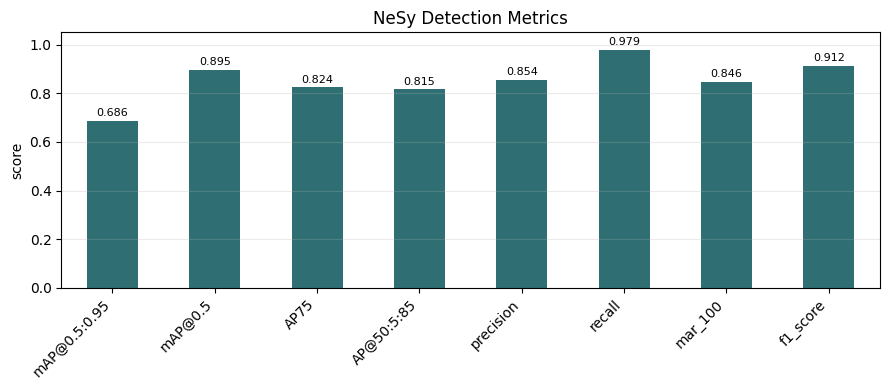

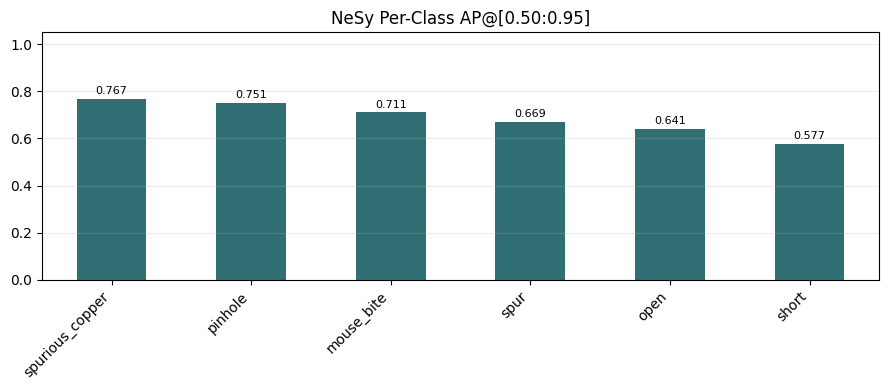

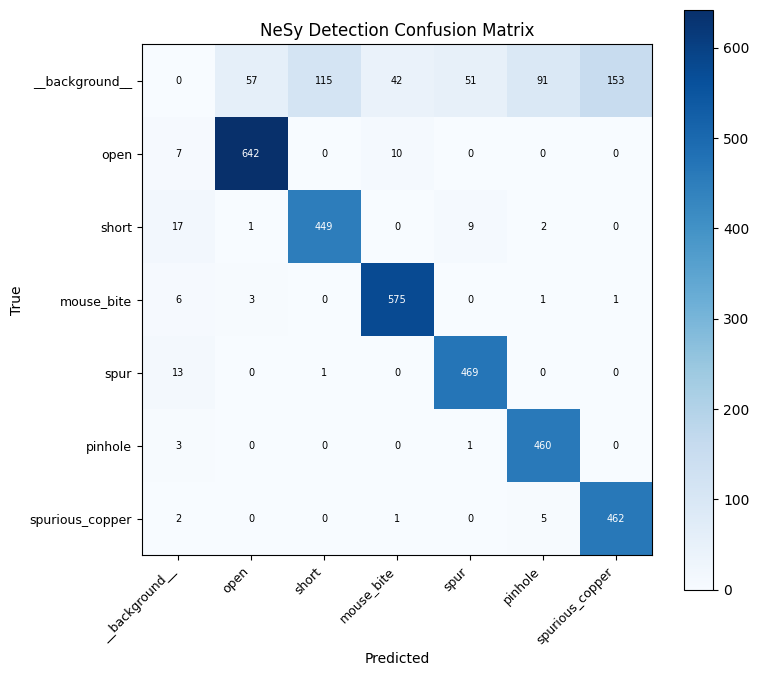

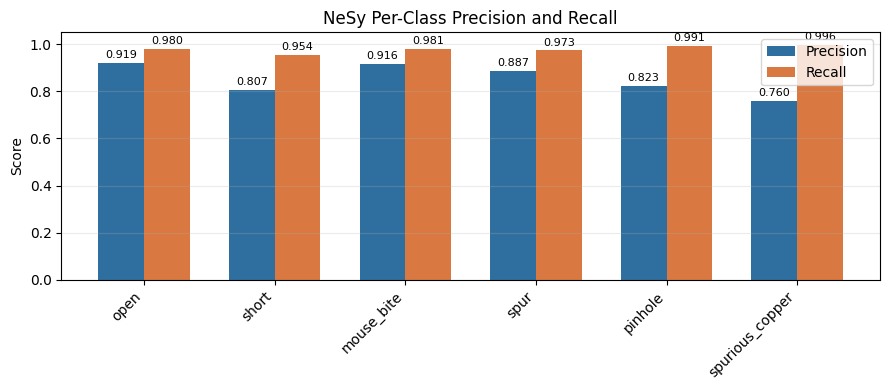

Inference time: 47.84 ms
Parameters: 36,228,914


,mAP@0.5:0.95,mAP@0.5,AP75,AP@50:5:85,precision,recall,mar_100,f1_score
0,0.685794,0.895176,0.824188,0.815277,0.853929,0.979299,0.846456,0.912328


In [31]:
test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.add_preprocess(test_preprocess())
test_loader = DataLoader(
    test_dataset,
    batch_size=train_config["dataset"]["batch_size"],
    shuffle=False,
    collate_fn=detection_collate_fn,
)
print(f"Test samples: {len(test_dataset)}")

metrics = evaluate_model(
    model=hybrid_model,
    data_loader=test_loader,
    device=device,
    train_config=train_config,
)

skip_keys = {"precision_recall_score_threshold", "inference_time_ms", "parameter_count"}
metric_frame = pd.DataFrame(
    [
        {
            key: value
            for key, value in metrics.items()
            if isinstance(value, (int, float)) and key not in skip_keys
        }
    ]
)
ax = metric_frame.T.plot(kind="bar", legend=False, figsize=(9, 4), color="#2f6f73")
ax.set_title("NeSy Detection Metrics")
ax.set_ylabel("score")
ax.set_ylim(0.0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if "per_class_AP" in metrics:
    s = pd.Series(metrics["per_class_AP"], name="AP").sort_values(ascending=False)
    ax = s.plot(kind="bar", figsize=(9, 4), color="#2f6f73")
    ax.set_title("NeSy Per-Class AP@[0.50:0.95]")
    ax.set_ylim(0.0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if "confusion_matrix" in metrics:
    cm = np.array(metrics["confusion_matrix"])
    labels = metrics["confusion_matrix_labels"]
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("NeSy Detection Confusion Matrix")
    cm_max = cm.max()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm_max * 0.5 else "black"
            ax.text(
                j, i, str(cm[i, j]), ha="center", va="center", fontsize=7, color=color
            )
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

if "per_class_precision" in metrics:
    pr = [k for k in metrics["per_class_precision"] if k != "__background__"]
    x = np.arange(len(pr))
    w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(
        x - w / 2,
        [metrics["per_class_precision"][c] for c in pr],
        w,
        label="Precision",
        color="#2F6F9F",
    )
    ax.bar(
        x + w / 2,
        [metrics["per_class_recall"][c] for c in pr],
        w,
        label="Recall",
        color="#D97941",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(pr, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("NeSy Per-Class Precision and Recall")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(ax.containers[1], fmt="%.3f", padding=2, fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f"Inference time: {metrics.get('inference_time_ms', 0):.2f} ms")
    print(f"Parameters: {metrics.get('parameter_count', 0):,}")

plt.close("all")
metric_frame

## Explanation Metrics

SODT explanation quality metrics evaluated on NeSy detections (full pipeline: FRCNN + SODT) over the test set.

In [32]:
tree = hybrid_model.symbolic_tree

all_features = []
all_grids = []
all_proposal_boxes = []
all_matched_gt_boxes = []
all_has_matched = []
all_gt_iou = []

for i in _tqdm(range(len(test_dataset)), desc="Collecting NeSy detections"):
    image, target = test_dataset[i]
    detection = run_neurosymbolic_inference(hybrid_model, [image])[0]
    n_det = detection["boxes"].shape[0]
    if n_det == 0:
        continue

    pooled = detection["pooled_features"]
    proposals = detection["proposal_boxes"]
    gt_boxes = target["boxes"]
    gt_labels = target["labels"]

    all_features.append(pooled.flatten(start_dim=1).numpy())
    all_grids.append(pooled.numpy())
    all_proposal_boxes.append(proposals)

    if gt_boxes.numel() > 0:
        overlaps = _box_iou(proposals, gt_boxes)
        matched_iou, matched_idx = overlaps.max(dim=1)
        matched_boxes = gt_boxes[matched_idx]
        has_match = matched_iou > 0
        all_matched_gt_boxes.append(matched_boxes)
        all_has_matched.append(has_match)
        all_gt_iou.append(matched_iou)
    else:
        all_matched_gt_boxes.append(torch.zeros((n_det, 4)))
        all_has_matched.append(torch.zeros(n_det, dtype=torch.bool))
        all_gt_iou.append(torch.zeros(n_det))

feature_matrix = np.concatenate(all_features, axis=0).astype(np.float32)
feature_grids = torch.from_numpy(np.concatenate(all_grids, axis=0))
all_proposals_t = torch.cat(all_proposal_boxes, dim=0)
all_matched_gt_t = torch.cat(all_matched_gt_boxes, dim=0)
all_has_matched_t = torch.cat(all_has_matched, dim=0)
all_gt_iou_t = torch.cat(all_gt_iou, dim=0)

nesy_pred = tree.predict_proba(feature_matrix).argmax(axis=1)

nesy_expl_metrics = evaluate_symbolic_model(
    tree,
    feature_matrix,
    nesy_pred,
    class_names,
)
nesy_spatial = evaluate_symbolic_spatial_metrics(
    tree,
    feature_grids,
    all_proposals_t,
    all_matched_gt_t,
    all_has_matched_t,
    all_gt_iou_t,
    heatmap_mode="leaf_only",
    min_proposal_iou=0.5,
)
nesy_expl_metrics.update(nesy_spatial)

print(f"Total NeSy detections: {feature_matrix.shape[0]:,}")
print(
    f"Sufficiency: {nesy_expl_metrics['sufficiency_prediction_preservation']:.4f}\n"
    f"Necessity flip rate: {nesy_expl_metrics['necessity_prediction_flip_rate']:.4f}\n"
    f"Deletion AUC: {nesy_expl_metrics['deletion_auc']:.4f}\n"
    f"Insertion AUC: {nesy_expl_metrics['insertion_auc']:.4f}\n"
    f"IoU overlap: {nesy_expl_metrics['box_grounded_roi_overlap']:.4f}\n"
    f"Pointing game: {nesy_expl_metrics['pointing_score']:.4f}"
)

Spatial grounding: 100%|██████████| 13434/13434 [00:01<00:00, 13002.89it/s]

Total NeSy detections: 13,434
Sufficiency: 1.0000
Necessity flip rate: 0.9999
Deletion AUC: 0.2272
Insertion AUC: 0.8048
IoU overlap: 0.9015
Pointing game: 0.9839


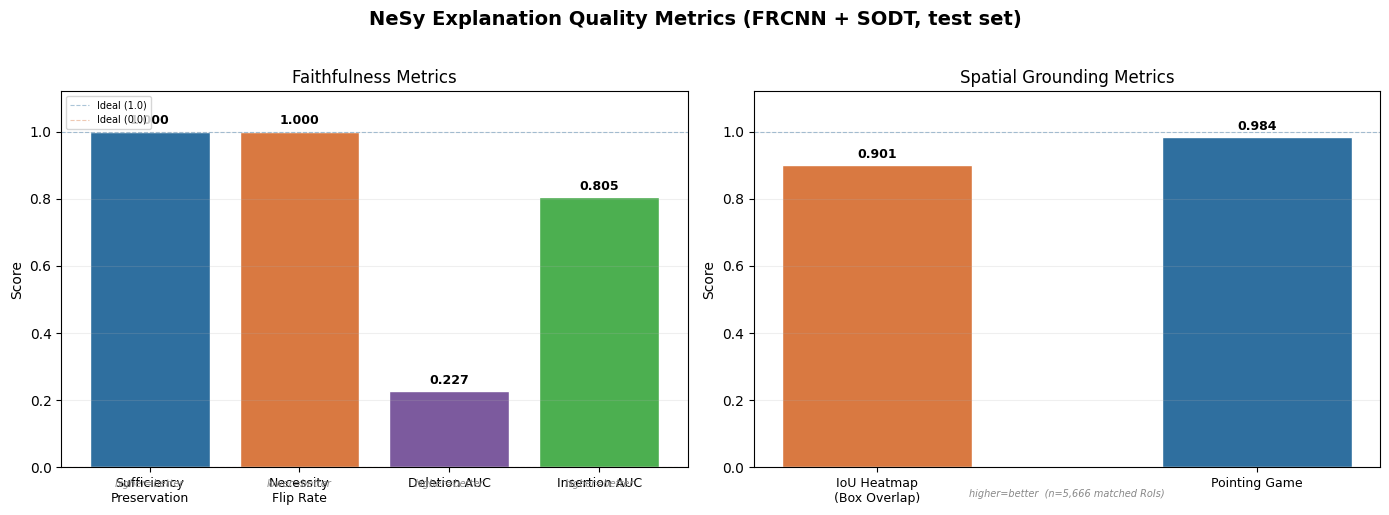

In [33]:
hm = nesy_expl_metrics

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "NeSy Explanation Quality Metrics (FRCNN + SODT, test set)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

# --- Panel 1: Faithfulness metrics ---
ax = axes[0]
faith_labels = [
    "Sufficiency\nPreservation",
    "Necessity\nFlip Rate",
    "Deletion AUC",
    "Insertion AUC",
]
faith_values = [
    hm.get("sufficiency_prediction_preservation", 0.0),
    hm.get("necessity_prediction_flip_rate", 0.0),
    hm.get("deletion_auc", 0.0),
    hm.get("insertion_auc", 0.0),
]
faith_colors = ["#2F6F9F", "#D97941", "#7C5A9E", "#4CAF50"]
bars = ax.bar(
    range(len(faith_labels)), faith_values, color=faith_colors, edgecolor="white"
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")
ax.set_xticks(range(len(faith_labels)))
ax.set_xticklabels(faith_labels, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Faithfulness Metrics")
ax.axhline(y=1.0, color="#2F6F9F", ls="--", lw=0.8, alpha=0.4, label="Ideal (1.0)")
ax.axhline(y=0.0, color="#D97941", ls="--", lw=0.8, alpha=0.4, label="Ideal (0.0)")
ax.legend(fontsize=7, loc="upper left")
ax.grid(axis="y", alpha=0.2)
for i, v in enumerate(faith_values):
    ax.text(
        i,
        -0.06,
        "lower=better" if i == 1 else "higher=better",
        ha="center",
        fontsize=7,
        color="#888888",
        style="italic",
    )

# --- Panel 2: Spatial grounding metrics ---
ax = axes[1]
spatial_labels = ["IoU Heatmap\n(Box Overlap)", "Pointing Game"]
spatial_values = [
    hm.get("box_grounded_roi_overlap", 0.0),
    hm.get("pointing_score", 0.0),
]
spatial_colors = ["#D97941", "#2F6F9F"]
bars = ax.bar(
    range(len(spatial_labels)),
    spatial_values,
    color=spatial_colors,
    edgecolor="white",
    width=0.5,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")
ax.set_xticks(range(len(spatial_labels)))
ax.set_xticklabels(spatial_labels, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Spatial Grounding Metrics")
ax.axhline(y=1.0, color="#2F6F9F", ls="--", lw=0.8, alpha=0.4)
ax.grid(axis="y", alpha=0.2)
n_eval = hm.get("evaluated_roi_count", 0)
ax.text(
    0.5,
    -0.08,
    f"higher=better  (n={n_eval:,} matched RoIs)",
    ha="center",
    fontsize=7,
    color="#888888",
    style="italic",
    transform=ax.transAxes,
)

plt.tight_layout()
plt.show()

In [34]:
def class_name(label: int) -> str:
    return class_names[int(label) - 1]

In [35]:
# Cleanup any stale figures / outputs from previous runs of this cell
import matplotlib.pyplot as plt

plt.close("all")
clear_output(wait=True)

upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
)
MAX_DISPLAY_DETECTIONS = 15
DISPLAY_SCORE_THRESHOLD = 0.3
detection_output = widgets.Output()
explanation_output = widgets.Output()
state = {
    "image_name": None,
    "image_tensor": None,
    "detection": None,
    "selected_indices": [],
}


def uploaded_file_record():
    value = upload_widget.value
    if isinstance(value, tuple):
        return value[0] if value else None
    if isinstance(value, dict):
        if "content" in value:
            return value
        return next(iter(value.values())) if value else None
    return None


def uploaded_content_bytes(file_record) -> bytes:
    content = file_record["content"]
    return content.tobytes() if isinstance(content, memoryview) else bytes(content)


def render_detection(detection_index: int) -> None:
    image_tensor = state["image_tensor"]
    detection = state["detection"]
    selected_indices = state["selected_indices"]
    explanation = explain_hybrid_detection(
        hybrid_model,
        detection,
        detection_index=detection_index,
        image_shape=tuple(image_tensor.shape[-2:]),
    )
    with explanation_output:
        clear_output(wait=True)
        selected_number = selected_indices.index(detection_index) + 1
        draw_neurosymbolic_explanation(
            image_tensor,
            detection,
            detection_index,
            explanation,
            class_names,
            hybrid_model.symbolic_tree,
            selected_number=selected_number,
        )


def make_detection_button(display_number: int, detection_index: int) -> widgets.Button:
    detection = state["detection"]
    label = int(detection["labels"][detection_index])
    score = float(detection["scores"][detection_index])
    button = widgets.Button(
        description=f"#{display_number} {class_name(label)} {score:.2f}",
        layout=widgets.Layout(width="180px"),
    )
    button.on_click(lambda _: render_detection(detection_index))
    return button


_processing_upload = False


def run_uploaded_inference(change=None) -> None:
    global _processing_upload
    if _processing_upload:
        return
    if change is not None and not change.get("new"):
        return
    _processing_upload = True
    try:
        file_record = uploaded_file_record()

        with detection_output:
            clear_output(wait=True)
        explanation_output.clear_output(wait=True)
        plt.close("all")

        if file_record is None:
            with detection_output:
                print("Upload one PCB image first.")
            return

        image_name = file_record.get("name", "uploaded_image")
        pil_image = Image.open(io.BytesIO(uploaded_content_bytes(file_record))).convert(
            "RGB"
        )
        image_tensor = image_preprocess(pil_image)
        detection = run_neurosymbolic_inference(hybrid_model, [image_tensor])[0]
        selected_indices = select_detection_indices(
            detection,
            score_threshold=DISPLAY_SCORE_THRESHOLD,
            max_detections=MAX_DISPLAY_DETECTIONS,
        )

        state["image_name"] = image_name
        state["image_tensor"] = image_tensor
        state["detection"] = detection
        state["selected_indices"] = selected_indices

        with detection_output:
            fig, axis = plt.subplots(figsize=(8, 8))
            draw_numbered_detections(
                axis, image_tensor, detection, selected_indices, class_names
            )
            axis.set_title(f"Neuro-Symbolic detections: {image_name}")
            plt.show()
            plt.close(fig)

            if not selected_indices:
                print("No detections were returned by the model.")
                return

            buttons = [
                make_detection_button(display_number, detection_index)
                for display_number, detection_index in enumerate(
                    selected_indices, start=1
                )
            ]
            display(
                widgets.GridBox(
                    buttons,
                    layout=widgets.Layout(
                        grid_template_columns="repeat(3, 190px)",
                        grid_gap="8px",
                    ),
                )
            )

        if selected_indices:
            render_detection(selected_indices[0])
    finally:
        _processing_upload = False


upload_widget.observe(run_uploaded_inference, names="value")

ui = widgets.VBox(
    [
        upload_widget,
        detection_output,
        explanation_output,
    ]
)
display(ui)